# Loan Approval Prediction Using Machine Learning

## Introduction

Loan approval prediction is an important application of machine learning in the banking and finance sector. Financial institutions receive many loan applications every day, and analyzing them manually can be time-consuming and error-prone.

In this project, machine learning techniques are used to predict whether a loan application will be approved or rejected based on applicant details such as income, education, credit history, employment status, and loan amount.

The project demonstrates the complete supervised learning workflow including data preprocessing, exploratory data analysis, model training, evaluation, and performance visualization.

## Objective

The main objective of this project is to build a predictive machine learning model that can accurately determine loan approval status using applicant information.

The project aims to:
- Perform data preprocessing and cleaning
- Analyze relationships between variables
- Train multiple machine learning models
- Evaluate model performance using accuracy, confusion matrix, and ROC curve
- Identify the most effective prediction model

## Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


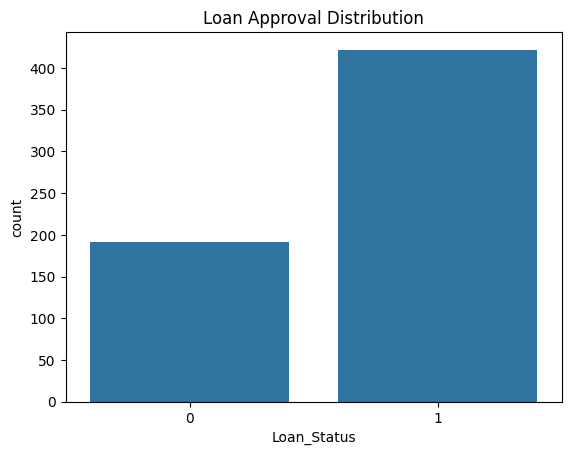

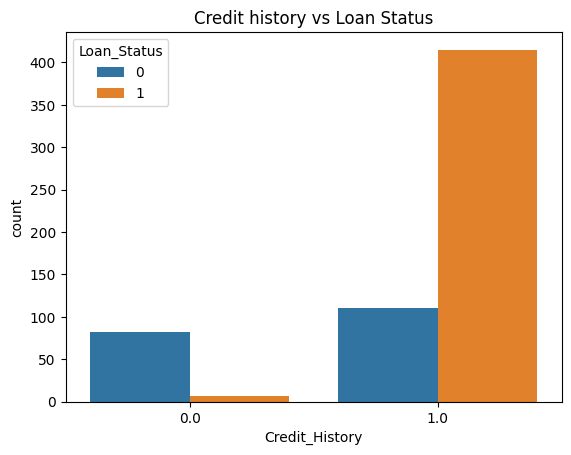

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.7886178861788617
Random Forest Accuracy: 0.7560975609756098


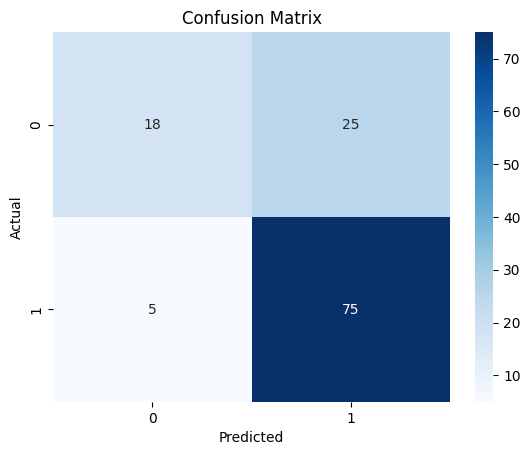

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



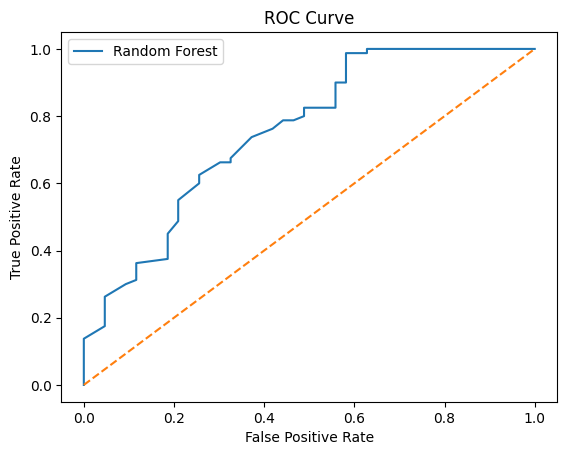

ROC_AUC Score: 0.7552325581395348
Output CSV saved successfully.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

df = pd.read_csv('/content/sample_data/train_u6lujuX_CVtuZ9i.csv')

df.head()

df.info()

df.isnull().sum()

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

le = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for column in categorical_columns:
  df[column] = le.fit_transform(df[column])

df.drop('Loan_ID', axis=1, inplace=True)

# Exploratory Data Analysis
sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")

plt.show()

# Credit History Analysis
sns.countplot(x='Credit_History',hue='Loan_Status',data=df)

plt.title("Credit history vs Loan Status")

plt.show()

# Feature Selection
x = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Model Training
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, rf_pred))

# ROC Curve
rf_probs = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

plt.plot(fpr, tpr, label ='Random Forest')

plt.plot([0,1], [0,1], linestyle ='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

auc_score = roc_auc_score(y_test, rf_probs)

print("ROC_AUC Score:", auc_score)


output = pd.DataFrame({
    'Actual': y_test,
    'Predicted': rf_pred
})

output.to_csv('output_predictions.csv', index=False)

print("Output CSV saved successfully.")

## Conclusion

In this project, machine learning models were developed to predict loan approval status using applicant information. Logistic Regression, Decision Tree, and Random Forest algorithms were implemented and evaluated.

Among all models, Random Forest achieved the best performance with higher accuracy and ROC-AUC score. The project successfully demonstrated data preprocessing, supervised learning, model evaluation, and visualization techniques used in predictive analytics.